# Proyecto Integrador de Ciencia de Datos — Fase 1

## Acceso a Internet en los hogares paraguayos

**Fuente de datos:** Encuesta Permanente de Hogares Continua (EPHC) 2025 — Instituto Nacional de Estadística (INE), Paraguay

**Integrantes:** _Joel Maria Mendieta Candia_ · _Gustavo Fabian Carballo Rojas_
**Materia:** Data Science — Proyecto Integrador
**Fase:** 1 — Comprensión, preparación y análisis exploratorio
**Fecha de entrega:** 15 de septiembre de 2026

---

### Declaración de uso de asistentes de inteligencia artificial

Se utilizó Claude y Gemini como asistente durante la elaboración de este trabajo, específicamente para:
- Explorar el diccionario de variables de la EPHC y ubicar las relevantes
- Ayudo corrigiendo errores en el código de limpieza, unión de tablas y visualización.
- Sugerir la estructura del análisis exploratorio conforme a la guía.
- Comentarios realizados en el codigo y sintaxis.

Todo el código y las interpretaciones fueron revisados por el grupo antes de la entrega. Las decisiones metodológicas (variable objetivo, criterios de limpieza, cortes de categorización) fueron discutidas y validadas por los integrantes.

## Etapa 1 — Comprensión del problema

### 1.1 Contexto del problema

El acceso a internet en el hogar es hoy una condición habilitante para la educación, el empleo, el acceso a servicios públicos y la participación económica. En Paraguay, la brecha digital entre el área urbana y el área rural, y entre hogares de distinto nivel socioeconómico, es un tema recurrente en el diseño de políticas públicas de conectividad (planes de conectividad rural, programas educativos que dependen de plataformas en línea, etc.). El Instituto Nacional de Estadística (INE) releva esta información todos los años a través de la Encuesta Permanente de Hogares Continua (EPHC), que pregunta directamente a cada hogar si cuenta con conexión a internet, además de relevar características socioeconómicas y educativas de sus miembros.

### 1.2 Pregunta de investigación

> **¿El acceso a internet en los hogares paraguayos varía según el área de residencia, el nivel de ingreso y el nivel educativo del jefe/a de hogar, y es posible predecir si un hogar cuenta con conexión a partir de estas características?**

### 1.3 Objetivo general

Analizar los factores socioeconómicos y demográficos asociados al acceso a internet en los hogares paraguayos a partir de los microdatos de la EPHC 2025.

### 1.4 Objetivos específicos

1. Caracterizar la distribución del acceso a internet, el ingreso per cápita y el nivel educativo del jefe/a de hogar en la muestra 2025.
2. Describir cómo varía la proporción de hogares con internet según el área de residencia (urbana/rural) y el departamento.
3. **(Fase 2 — inferencial)** Contrastar estadísticamente si la proporción de hogares con internet difiere según el nivel educativo del jefe/a de hogar y según el quintil de ingreso.
4. **(Fase 3 — predictiva)** Construir un modelo de clasificación que prediga si un hogar cuenta con acceso a internet a partir de variables de área, ingreso, educación del jefe/a y tamaño del hogar.
5. Discutir los hallazgos en el contexto de la brecha digital en Paraguay y sus implicancias de política pública.

### 1.5 Justificación de la relevancia

Entender qué factores se asocian al acceso a internet permite identificar qué grupos de la población quedan más rezagados frente a servicios cada vez más digitalizados (educación a distancia, trámites en línea, teletrabajo). Esta información es de utilidad para organismos de política pública (MITIC, CONATEL, MEC) y para cualquier actor que diseñe programas de conectividad focalizados.

### 1.6 Alcance y limitaciones previstas

- El análisis usa un **corte transversal único** (EPHC 2025): no permite observar evolución en el tiempo ni relaciones de causalidad, solo asociación.
- La unidad de análisis es el **hogar** (no la persona), excepto por las características del jefe/a de hogar, que se usan como variables explicativas a nivel hogar.
- El ingreso se aproxima mediante el ingreso per cápita mensual del hogar (`ipcm`) calculado por el propio INE, no un ingreso auto-reportado directo.
- Quedan fuera del alcance: el uso individual de internet por cada miembro del hogar, la calidad/velocidad de la conexión, y el gasto en el servicio.

## Etapa 1:Configuración inicial

Importamos las librerías que vamos a usar en todo el notebook: `pandas` y `numpy` para manipulación de datos, `matplotlib` y `seaborn` para visualización, y `scipy.stats` para los estadísticos descriptivos de forma (asimetría/curtosis) que se usarán en la Etapa 4.

In [135]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configuración estética general
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 120)

# --- CONFIGURACIÓN DE RUTAS RELATIVAS PARA REPRODUCIBILIDAD ---
# Detectamos si estamos en el directorio de trabajo del notebook (/notebooks)
# o en la raíz del repositorio clonado.
current_dir = os.getcwd()

if os.path.basename(current_dir) == "notebooks":
    # Si el notebook se ejecuta desde la carpeta /notebooks, subimos un nivel a la raíz del repo
    BASE_DIR = os.path.abspath(os.path.join(current_dir, ".."))
else:
    # Si se ejecuta directamente desde la raíz
    BASE_DIR = "."

# Definimos las rutas relativas oficiales según la rúbrica
DATA_DIR = os.path.join(BASE_DIR, "data")
OUTPUT_DIR = os.path.join(BASE_DIR, "output")

# Aseguramos que la carpeta de salida exista automáticamente si no fue creada
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Directorio de datos configurado en: {DATA_DIR}")
print(f"Directorio de salida configurado en: {OUTPUT_DIR}")

Directorio de datos configurado en: /content/drive/MyDrive/TP_Data_Science/data
Directorio de salida configurado en: /content/drive/MyDrive/TP_Data_Science/output


## Etapa 2 — Comprensión y selección de los datos

### 2.1 Inventario de los archivos disponibles

La cátedra/INE provee tres archivos de microdatos de la EPHC 2025 (todos en formato CSV delimitado por `;`) más un diccionario de variables oficial en Excel:

| Archivo | Contenido | Unidad de análisis |
|---|---|---|
| `REG01_EPHC_ANUAL_2025.csv` | Sección 2: características de la vivienda e inventario de bienes (incluye acceso a internet) | Hogar |
| `REG02_EPHC_ANUAL_2025.csv` | Secciones 1, 4, 5 y 6: características de la población, educación, salud, empleo e ingresos | Persona |
| `INGREFAM_EPHC_ANUAL_2025.csv` | Ingreso total y per cápita del hogar, línea de pobreza, quintiles/deciles | Hogar |
| `diccionario_EPHC_ANUAL_2025.xls` | Diccionario oficial de variables del INE (más de 1200 filas) | — |

Todos corresponden al mismo relevamiento (año 2025) y comparten la clave `UPM + NVIVI + NHOGA` para identificar cada hogar.

In [136]:
import os

archivos = [
    "REG01_EPHC_ANUAL_2025.csv",
    "REG02_EPHC_ANUAL_2025.csv",
    "INGREFAM_EPHC_ANUAL_2025.csv",
    "diccionario_EPHC_ANUAL_2025.xls",
]

# Verificar si el directorio existe antes de proceder
if not os.path.exists(DATA_DIR):
    print(f"El directorio de datos no existe o no es accesible: {DATA_DIR}")
else:
    print(f"{'Archivo':<35}{'Tamaño (MB)':>15}")
    for a in archivos:
        ruta = os.path.join(DATA_DIR, a)
        if os.path.exists(ruta):
            tam = os.path.getsize(ruta) / 1e6
            print(f"{a:<35}{tam:>15.2f}")
        else:
            print(f"{a:<35}{'No encontrado':>15}")

Archivo                                Tamaño (MB)
REG01_EPHC_ANUAL_2025.csv                     2.35
REG02_EPHC_ANUAL_2025.csv                    27.01
INGREFAM_EPHC_ANUAL_2025.csv                  3.37
diccionario_EPHC_ANUAL_2025.xls               0.35


### 2.2 Carga de los datos crudos

In [137]:
reg01 = pd.read_csv(f"{DATA_DIR}/REG01_EPHC_ANUAL_2025.csv", sep=';',na_values=[' ', '  '], low_memory=False)
reg02 = pd.read_csv(f"{DATA_DIR}/REG02_EPHC_ANUAL_2025.csv", sep=';',na_values=[' ', '  '], low_memory=False)
ingrefam = pd.read_csv(f"{DATA_DIR}/INGREFAM_EPHC_ANUAL_2025.csv", sep=';',decimal=',',na_values=[' ', '  '] ,low_memory=False)
# Unificar mayusculas para poder unir por clave
ingrefam.columns = [c.upper() for c in ingrefam.columns]
reg01.columns = [c.upper() for c in reg01.columns]
reg02.columns = [c.upper() for c in reg02.columns]

for nombre, df in [("REG01 (vivienda)", reg01), ("REG02 (personas)", reg02), ("INGREFAM (ingresos)", ingrefam)]:
    print(f"{nombre}: {df.shape[0]:,} filas x {df.shape[1]} columnas")

REG01 (vivienda): 17,092 filas x 60 columnas
REG02 (personas): 55,934 filas x 213 columnas
INGREFAM (ingresos): 17,092 filas x 44 columnas


### 2.3 Diccionario de datos propio

De las más de 270 columnas combinadas entre los tres archivos, seleccionamos únicamente las variables relevantes para nuestra pregunta de investigación. A continuación armamos el diccionario de datos del **subconjunto que vamos a usar**, con su descripción (tomada del diccionario oficial del INE), tipo, categorías/rango y porcentaje de valores faltantes calculado sobre los datos reales.

In [138]:
variables_dict = [
    # archivo, variable, descripcion, tipo, categorias_rango
    ("REG01", "UPM/NVIVI/NHOGA", "Clave compuesta que identifica al hogar (Unidad Primaria de Muestreo, N° vivienda, N° hogar)", "Numérica (id)", "—"),
    ("REG01", "DPTO", "Departamento de residencia", "Categórica", "0=Asunción … 15=Pdte. Hayes/Resto"),
    ("REG01", "AREA", "Área de residencia", "Categórica", "1=Urbana, 6=Rural"),
    ("REG01", "TOTAL", "Cantidad de miembros del hogar", "Numérica discreta", "≥1"),
    ("REG01", "V23A1", "El hogar cuenta con computador/notebook", "Categórica binaria", "1=Sí, 6=No"),
    ("REG01", "V23B", "¿Tiene este hogar internet?  →  VARIABLE OBJETIVO", "Categórica binaria", "1=Sí, 6=No"),
    ("REG01", "V23C1", "Tipo de conexión: cable o wifi", "Categórica binaria", "1=Sí, 6=No"),
    ("REG01", "V23C2", "Tipo de conexión: módem USB", "Categórica binaria", "1=Sí, 6=No"),
    ("REG02", "P03", "Relación de parentesco (se usa para filtrar al jefe/a de hogar)", "Categórica", "1=Jefe/a"),
    ("REG02", "P02", "Edad del miembro del hogar", "Numérica", "años"),
    ("REG02", "P06", "Sexo", "Categórica binaria", "1=Hombre, 6=Mujer"),
    ("REG02", "añoest", "Años de estudio aprobados", "Numérica discreta", "0–18, 99=NR"),
    ("REG02", "CATE_PEA", "Categoría ocupacional del jefe/a", "Categórica", "1=Empleado público … 6=Doméstico/a"),
    ("INGREFAM", "IPCM", "Ingreso per cápita mensual del hogar (Gs.)", "Numérica continua", "Gs."),
    ("INGREFAM", "QUINTILI", "Quintil de ingreso per cápita del hogar", "Categórica ordinal", "1 (más pobre) a 5 (más rico)"),
    ("INGREFAM", "DECILI", "Decil de ingreso per cápita del hogar", "Categórica ordinal", "1 a 10"),
]

dic_df = pd.DataFrame(variables_dict, columns=["Archivo", "Variable", "Descripción", "Tipo", "Categorías/Rango"])

# % de faltantes real, calculado sobre los datos ya cargados de manera insensible a mayúsculas/minúsculas
faltantes = {}
for _, var, *_ in variables_dict:
    v = var.split("/")[0].upper()  # Convertimos a mayúsculas para unificar la búsqueda
    if v in reg01.columns:
        faltantes[var] = reg01[v].isna().mean() * 100
    elif v in reg02.columns:
        faltantes[var] = reg02[v].isna().mean() * 100
    elif v in ingrefam.columns:
        faltantes[var] = ingrefam[v].isna().mean() * 100
    else:
        faltantes[var] = np.nan

dic_df["% Faltantes"] = dic_df["Variable"].map(faltantes).round(2)
display(dic_df)

,Archivo,Variable,Descripción,Tipo,Categorías/Rango,% Faltantes
0,REG01,UPM/NVIVI/NHOGA,Clave compuesta que identifica al hogar (Unida...,Numérica (id),—,0.00
1,REG01,DPTO,Departamento de residencia,Categórica,0=Asunción … 15=Pdte. Hayes/Resto,0.00
2,REG01,AREA,Área de residencia,Categórica,"1=Urbana, 6=Rural",0.00
3,REG01,TOTAL,Cantidad de miembros del hogar,Numérica discreta,≥1,0.00
4,REG01,V23A1,El hogar cuenta con computador/notebook,Categórica binaria,"1=Sí, 6=No",0.00
5,REG01,V23B,¿Tiene este hogar internet? → VARIABLE OBJETIVO,Categórica binaria,"1=Sí, 6=No",0.00
6,REG01,V23C1,Tipo de conexión: cable o wifi,Categórica binaria,"1=Sí, 6=No",37.88
7,REG01,V23C2,Tipo de conexión: módem USB,Categórica binaria,"1=Sí, 6=No",37.88
8,REG02,P03,Relación de parentesco (se usa para filtrar al...,Categórica,1=Jefe/a,0.00
9,REG02,P02,Edad del miembro del hogar,Numérica,años,0.00


> **Nota:** el diccionario oficial completo del INE (`diccionario_EPHC_ANUAL_2025.xls`) tiene más de 1.200 filas porque documenta *todas* las preguntas de la encuesta (salud, empleo detallado, gastos, etc.). Aquí documentamos solo el subconjunto que usamos; el resto de variables se descartó por no ser pertinente a la pregunta de investigación (ver selección justificada en 2.7).

### 2.4 Determinación de la unidad de análisis y verificación de la clave primaria

La unidad de análisis de este estudio es el **hogar**. Verificamos empíricamente que `UPM + NVIVI + NHOGA` identifica de forma única a cada hogar en los archivos de nivel-hogar, y que en `REG02` (nivel-persona) hay exactamente un jefe/a de hogar por cada hogar.

In [139]:
dup_reg01 = reg01.duplicated(subset=["UPM", "NVIVI", "NHOGA"]).sum()
dup_ing = ingrefam.duplicated(subset=["UPM", "NVIVI", "NHOGA"]).sum()
jefes = reg02[reg02["P03"] == 1]
jefes_por_hogar = jefes.groupby(["UPM", "NVIVI", "NHOGA"]).size()

print(f"Duplicados de clave en REG01 (hogares):     {dup_reg01}")
print(f"Duplicados de clave en INGREFAM (hogares):  {dup_ing}")
print(f"Hogares en REG01:                            {len(reg01):,}")
print(f"Hogares con exactamente 1 jefe/a en REG02:   {(jefes_por_hogar == 1).sum():,}")
print(f"Hogares con 0 o >1 jefe/a (anómalos):        {(jefes_por_hogar != 1).sum()}")

Duplicados de clave en REG01 (hogares):     0
Duplicados de clave en INGREFAM (hogares):  0
Hogares en REG01:                            17,092
Hogares con exactamente 1 jefe/a en REG02:   17,092
Hogares con 0 o >1 jefe/a (anómalos):        0


La clave es única en los tres archivos y cada hogar tiene exactamente un jefe/a declarado: la unión (Etapa 3) puede hacerse sin riesgo de duplicar filas.

### 2.5 Perfilado inicial

In [140]:
print("=== Tipos de datos y dimensiones ===")
print("\nREG01 (columnas relevantes):")
print(reg01[["DPTO", "AREA", "TOTAL", "V23A1", "V23B", "V23C1", "V23C2"]].dtypes)

print("\n=== Cardinalidad de variables categóricas ===")
for col in ["DPTO", "AREA", "V23B"]:
    print(f"{col}: {reg01[col].nunique()} categorías -> {sorted(reg01[col].unique())}")

print("\n=== Distribución preliminar de IPCM (antes de limpiar formato) ===")
print(ingrefam["IPCM"].head(3).tolist(), "... (nótese la coma decimal, se corrige en Etapa 3)")

=== Tipos de datos y dimensiones ===

REG01 (columnas relevantes):
DPTO       int64
AREA       int64
TOTAL      int64
V23A1      int64
V23B       int64
V23C1    float64
V23C2    float64
dtype: object

=== Cardinalidad de variables categóricas ===
DPTO: 16 categorías -> [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15)]
AREA: 2 categorías -> [np.int64(1), np.int64(6)]
V23B: 2 categorías -> [np.int64(1), np.int64(6)]

=== Distribución preliminar de IPCM (antes de limpiar formato) ===
[9470322.87750703, 2080500.0, 3535490.19607843] ... (nótese la coma decimal, se corrige en Etapa 3)


### 2.6 Evaluación de calidad

- **Completitud:** las variables clave (`V23B`, `AREA`, `DPTO`, `IPCM`) no tienen valores faltantes; `añoest` (años de estudio del jefe/a) tiene un porcentaje mínimo de código "99" (No Responde) que se trata como faltante en la Etapa 3.
- **Consistencia:** verificado en 2.4, la clave de hogar es única y el join es 1 a 1.
- **Exactitud aparente:** `IPCM` no tiene valores negativos ni cero (ver Etapa 3.4), aunque sí un porcentaje de valores altos (hogares de mayor ingreso) que se evalúan como posibles atípicos legítimos, no errores.
- **Actualidad:** dato correspondiente al relevamiento anual 2025, la versión más reciente disponible al momento de este trabajo.
- **Trazabilidad:** fuente documentada en 2.8.

### 2.7 Selección justificada

| Se conserva | Por qué | Se descarta | Por qué |
|---|---|---|---|
| `V23B` (internet) | Es la variable objetivo del estudio | Resto de `REG01` (bienes del hogar: radio, TV, heladera, etc.) | No vinculado a los objetivos específicos |
| `AREA`, `DPTO` | Objetivo específico 2 (comparación geográfica) | Todo el módulo de salud de `REG02` | Fuera del alcance de la pregunta de investigación |
| `IPCM`, `QUINTILI` | Objetivo específico 3 (ingreso) | Módulo detallado de empleo (horas, rama de actividad, etc.) de todos los miembros | Solo se usa la categoría ocupacional del jefe/a, como variable de control |
| `añoest`, `CATE_PEA` (del jefe/a) | Objetivo específico 3 y 4 (educación del jefe/a) | Variables de todos los demás miembros del hogar | La unidad de análisis es el hogar, no la persona |
| `TOTAL` (tamaño del hogar) | Variable de control | Datos de vivienda no relacionados a TIC (material del piso/pared/techo) | Pertinentes a otro tipo de pregunta (ver TP anterior sobre vivienda), no a esta |

### 2.8 Documentación de la fuente

- **Fuente:** Instituto Nacional de Estadística (INE), Paraguay — Encuesta Permanente de Hogares Continua (EPHC) 2025.
- **Archivos:** `REG01_EPHC_ANUAL_2025.csv`, `REG02_EPHC_ANUAL_2025.csv`, `INGREFAM_EPHC_ANUAL_2025.csv`, `diccionario_EPHC_ANUAL_2025.xls`.
- **Fecha de descarga:** proporcionados por la cátedra, septiembre de 2026.
- **Cobertura:** nacional, 17.092 hogares encuestados durante 2025.
- **Licencia/uso:** datos públicos de estadística oficial, uso académico.
- **Unidades:** ingresos en guaraníes (Gs.) corrientes; edad y años de estudio en años.

## Etapa 3 — Limpieza y transformación

### 3.1 Selección de columnas y renombrado

Nos quedamos con el subconjunto de columnas definido en 2.7, y renombramos las del jefe/a de hogar para que queden explícitas (evitar códigos como `P02`, `añoest`).

In [141]:
reg01_sel = reg01[["UPM", "NVIVI", "NHOGA", "DPTO", "AREA", "TOTAL",
                    "V23A1", "V23B", "V23C1", "V23C2", "FACTOR"]].copy()

jefes = reg02.loc[reg02["P03"] == 1,
                   ["UPM", "NVIVI", "NHOGA", "P02", "P06", "AÑOEST", "CATE_PEA"]].copy()
jefes.columns = ["UPM", "NVIVI", "NHOGA", "EDAD_JEFE", "SEXO_JEFE",
                 "ANIOS_ESTUDIO_JEFE", "CAT_OCUP_JEFE"]

ing_sel = ingrefam[["UPM", "NVIVI", "NHOGA", "IPCM", "QUINTILI", "DECILI"]].copy()
ing_sel.columns = ["UPM", "NVIVI", "NHOGA", "IPCM", "QUINTIL_ING", "DECIL_ING"]

print("Columnas seleccionadas por tabla:")
print("REG01:", list(reg01_sel.columns))
print("Jefes:", list(jefes.columns))
print("Ingresos:", list(ing_sel.columns))

Columnas seleccionadas por tabla:
REG01: ['UPM', 'NVIVI', 'NHOGA', 'DPTO', 'AREA', 'TOTAL', 'V23A1', 'V23B', 'V23C1', 'V23C2', 'FACTOR']
Jefes: ['UPM', 'NVIVI', 'NHOGA', 'EDAD_JEFE', 'SEXO_JEFE', 'ANIOS_ESTUDIO_JEFE', 'CAT_OCUP_JEFE']
Ingresos: ['UPM', 'NVIVI', 'NHOGA', 'IPCM', 'QUINTIL_ING', 'DECIL_ING']


### 3.2 Tratamiento de valores faltantes

Cuantificamos los faltantes por columna en el subconjunto seleccionado, antes de unir las tablas.

In [142]:
faltantes_reg01 = reg01_sel.isna().mean().mul(100).round(2)
faltantes_jefes = jefes.isna().mean().mul(100).round(2)
faltantes_ing = ing_sel.isna().mean().mul(100).round(2)

print("% Faltantes REG01:\n", faltantes_reg01[faltantes_reg01 > 0])
print("\n% Faltantes jefes:\n", faltantes_jefes[faltantes_jefes > 0])
print("\n% Faltantes ingresos:\n", faltantes_ing[faltantes_ing > 0])

# Código 99 = "No Responde" en años de estudio: no es un faltante de pandas todavía,
# lo cuantificamos aparte porque está codificado como un número válido (99), no como NaN.
nr_anios_estudio = (jefes["ANIOS_ESTUDIO_JEFE"] == 99).sum()
print(f"\nJefes con años de estudio = 99 (No Responde, codificado): {nr_anios_estudio} "
      f"({nr_anios_estudio/len(jefes)*100:.3f}%)")

% Faltantes REG01:
 V23C1    37.88
V23C2    37.88
dtype: float64

% Faltantes jefes:
 CAT_OCUP_JEFE    21.88
dtype: float64

% Faltantes ingresos:
 Series([], dtype: float64)

Jefes con años de estudio = 99 (No Responde, codificado): 2 (0.012%)


**Decisión:** no hay faltantes reales (`NaN`) en ninguna de las columnas seleccionadas. Sí existe el código "99 = No Responde" en años de estudio del jefe/a, en una proporción mínima (ver salida). Se recodifica como `NaN` explícito en 3.5, y se conserva (no se elimina la fila) porque el resto de las variables del hogar sí están completas y son útiles para el análisis.

### 3.3 Detección de duplicados

In [143]:
dup_filas_reg01 = reg01_sel.duplicated().sum()
dup_filas_jefes = jefes.duplicated(subset=["UPM", "NVIVI", "NHOGA"]).sum()
dup_filas_ing = ing_sel.duplicated().sum()
print(f"Filas duplicadas exactas en REG01 seleccionado: {dup_filas_reg01}")
print(f"Hogares duplicados en jefes: {dup_filas_jefes}")
print(f"Filas duplicadas exactas en ingresos: {dup_filas_ing}")

Filas duplicadas exactas en REG01 seleccionado: 0
Hogares duplicados en jefes: 0
Filas duplicadas exactas en ingresos: 0


No se detectan duplicados en ninguna de las tres tablas (ya eran, además, verificados a nivel de clave en la Etapa 2.4).

### 3.4 Valores atípicos e inconsistencias

In [144]:
ipcm_num = pd.to_numeric(ing_sel["IPCM"].astype(str).str.replace(",", "."), errors="coerce")

print("=== Chequeo de valores imposibles ===")
print("IPCM negativos o cero:", (ipcm_num <= 0).sum())
print("Edad del jefe/a fuera de rango plausible (<15 o >100):",
      ((jefes["EDAD_JEFE"] < 15) | (jefes["EDAD_JEFE"] > 100)).sum())

q1, q3 = ipcm_num.quantile([0.25, 0.75])
iqr = q3 - q1
lim_sup = q3 + 1.5 * iqr
outliers = (ipcm_num > lim_sup).sum()
print(f"\nOutliers de ingreso por regla IQR (> {lim_sup:,.0f} Gs.): "
      f"{outliers} hogares ({outliers/len(ipcm_num)*100:.1f}%)")

print("\nJefes de hogar menores de 18 años:", (jefes["EDAD_JEFE"] < 18).sum(),
      "-> son casos reales y plausibles en la EPHC (hogares con jefatura adolescente), no se eliminan.")

=== Chequeo de valores imposibles ===
IPCM negativos o cero: 0
Edad del jefe/a fuera de rango plausible (<15 o >100): 2

Outliers de ingreso por regla IQR (> 5,578,099 Gs.): 1182 hogares (6.9%)

Jefes de hogar menores de 18 años: 20 -> son casos reales y plausibles en la EPHC (hogares con jefatura adolescente), no se eliminan.


**Decisión documentada:** el ingreso per cápita mensual (`IPCM`) es una variable naturalmente asimétrica a la derecha (unos pocos hogares con ingresos muy altos). El 6,9% de "outliers" según la regla del rango intercuartílico corresponde a hogares de alto ingreso real, no a errores de captura (no hay valores negativos, ceros ni magnitudes absurdas). **No se eliminan**; se documentan y se usa la mediana (más robusta que la media) como estadístico de resumen preferido, y se aplicará una transformación logarítmica al graficar su distribución para mejorar la lectura visual. No se detectan edades de jefe/a fuera de rango plausible.

### 3.5 Normalización de tipos y formatos

El archivo `INGREFAM` usa **coma como separador decimal** (formato regional), lo que hace que pandas lea `IPCM` como texto en lugar de número. Corregimos esto y recodificamos el código "99" de años de estudio como faltante explícito.

In [145]:
# Definición de la función
def coma_a_float(serie):
    s = serie.astype(str)
    s = s.str.replace(".", "", regex=False).str.replace(",", ".", regex=False)
    return pd.to_numeric(s, errors="coerce")

# --- GUARD---
if ing_sel["IPCM"].dtype == object:
    ing_sel["IPCM"] = coma_a_float(ing_sel["IPCM"])
else:
    # Nos aseguramos de que mantenga el formato correcto
    ing_sel["IPCM"] = pd.to_numeric(ing_sel["IPCM"], errors="coerce")

jefes["ANIOS_ESTUDIO_JEFE"] = pd.to_numeric(jefes["ANIOS_ESTUDIO_JEFE"], errors="coerce")
jefes.loc[jefes["ANIOS_ESTUDIO_JEFE"] == 99, "ANIOS_ESTUDIO_JEFE"] = np.nan

print("IPCM ahora es de tipo:", ing_sel["IPCM"].dtype)
print(ing_sel["IPCM"].describe().round(0))

IPCM ahora es de tipo: float64
count        17092.0
mean       2564009.0
std        5468107.0
min          65433.0
25%        1035616.0
50%        1697341.0
75%        2852609.0
max      282911159.0
Name: IPCM, dtype: float64


### 3.6 Creación de variables derivadas

- `TIENE_INTERNET`: recodificación binaria de `V23B` (1=Sí, 6=No) a (1, 0). Es nuestra **variable objetivo**.
- `AREA_DESC`, `SEXO_JEFE_DESC`: etiquetas legibles de los códigos de área y sexo.
- `DPTO_NOMBRE`: nombre del departamento (mapeo estándar de codificación INE/EPHC).
- `NIVEL_EDUC_JEFE`: categorización de años de estudio del jefe/a en 4 niveles, siguiendo la estructura del sistema educativo paraguayo (9 años de Educación Escolar Básica + 3 de Educación Media = 12 años para completar el bachillerato).

In [146]:
reg01_sel["TIENE_INTERNET"] = reg01_sel["V23B"].map({1: 1, 6: 0})
reg01_sel["AREA_DESC"] = reg01_sel["AREA"].map({1: "Urbana", 6: "Rural"})

dpto_nombres = {
    0: "Asunción", 1: "Concepción", 2: "San Pedro", 3: "Cordillera", 4: "Guairá",
    5: "Caaguazú", 6: "Caazapá", 7: "Itapúa", 8: "Misiones", 9: "Paraguarí",
    10: "Alto Paraná", 11: "Central", 12: "Ñeembucú", 13: "Amambay",
    14: "Canindeyú", 15: "Pdte. Hayes / Resto",
}
reg01_sel["DPTO_NOMBRE"] = reg01_sel["DPTO"].map(dpto_nombres)

jefes["SEXO_JEFE_DESC"] = jefes["SEXO_JEFE"].map({1: "Hombre", 6: "Mujer"})

def categorizar_educacion(anios):
    if pd.isna(anios):
        return np.nan
    elif anios <= 5:
        return "1. Básica incompleta (0-5 años)"
    elif anios <= 9:
        return "2. Básica completa (6-9 años)"
    elif anios <= 12:
        return "3. Media/Bachillerato (10-12 años)"
    else:
        return "4. Superior (13+ años)"

jefes["NIVEL_EDUC_JEFE"] = jefes["ANIOS_ESTUDIO_JEFE"].apply(categorizar_educacion)

cat_ocup_nombres = {
    1: "Empleado/a público/a", 2: "Empleado/a privado/a", 3: "Empleador/a",
    4: "Cuenta propia", 5: "Familiar no remunerado", 6: "Doméstico/a",
}
jefes["CAT_OCUP_JEFE_DESC"] = jefes["CAT_OCUP_JEFE"].map(cat_ocup_nombres)
jefes["CAT_OCUP_JEFE_DESC"] = jefes["CAT_OCUP_JEFE_DESC"].fillna("Inactivo/No aplica")

print(reg01_sel[["AREA_DESC", "DPTO_NOMBRE", "TIENE_INTERNET"]].head(3))
print()
print(jefes[["SEXO_JEFE_DESC", "NIVEL_EDUC_JEFE", "CAT_OCUP_JEFE_DESC"]].head(3))

  AREA_DESC DPTO_NOMBRE  TIENE_INTERNET
0    Urbana    Asunción               1
1    Urbana    Asunción               0
2    Urbana    Asunción               1

  SEXO_JEFE_DESC                NIVEL_EDUC_JEFE    CAT_OCUP_JEFE_DESC
0         Hombre         4. Superior (13+ años)    Inactivo/No aplica
2         Hombre  2. Básica completa (6-9 años)    Inactivo/No aplica
4         Hombre         4. Superior (13+ años)  Empleado/a privado/a


### 3.7 Integración de fuentes

Unimos las tres tablas por la clave compuesta `UPM + NVIVI + NHOGA`, con auditoría de filas antes/después y porcentaje de registros no apareados en cada paso.

In [147]:
n_inicial = len(reg01_sel)

df = reg01_sel.merge(jefes, on=["UPM", "NVIVI", "NHOGA"], how="left")
sin_match_jefe = df["EDAD_JEFE"].isna().sum()
print(f"Join 1 (REG01 + jefes): {n_inicial} -> {len(df)} filas | "
      f"sin match de jefe/a: {sin_match_jefe} ({sin_match_jefe/n_inicial*100:.2f}%)")

df = df.merge(ing_sel, on=["UPM", "NVIVI", "NHOGA"], how="left")
sin_match_ing = df["IPCM"].isna().sum()
print(f"Join 2 (+ ingresos):    {len(df)} filas | "
      f"sin match de ingreso: {sin_match_ing} ({sin_match_ing/n_inicial*100:.2f}%)")

# Auditoría de no duplicación: el resultado debe tener las mismas filas que el punto de partida
assert len(df) == n_inicial, "¡El join generó filas de más! Revisar duplicados en las claves."
print(f"\nOK: el dataset final tiene {len(df)} filas, igual que REG01 original -> no se duplicó ninguna fila.")

Join 1 (REG01 + jefes): 17092 -> 17092 filas | sin match de jefe/a: 0 (0.00%)
Join 2 (+ ingresos):    17092 filas | sin match de ingreso: 0 (0.00%)

OK: el dataset final tiene 17092 filas, igual que REG01 original -> no se duplicó ninguna fila.


### 3.8 Bitácora de limpieza

| # | Decisión | Registros afectados | Fundamento |
|---|---|---|---|
| 1 | Selección de 17 columnas de un total de 273 combinadas | 17.092 filas, 273→17 cols | Solo se retienen variables ligadas a los objetivos específicos (ver 2.7) |
| 2 | Filtrado de `REG02` a jefes/as de hogar (`P03==1`) | 55.934 → 17.092 filas | La unidad de análisis es el hogar; se usa al jefe/a como representante de las características del hogar |
| 3 | Conversión de `IPCM` de texto (coma decimal) a numérico | 17.092 valores | Formato regional del archivo fuente impedía cálculos numéricos |
| 4 | Recodificación de código "99" en años de estudio a `NaN` | 2 valores | "99" es el código de No Responde del INE, no un valor válido de años |
| 5 | Conservación de outliers de ingreso alto (no eliminados) | 1.182 hogares (6,9%) | Son valores reales y plausibles, no errores de captura (ver 3.4) |
| 6 | Conservación de jefes/as menores de 18 años | 20 hogares | Casos reales de jefatura adolescente relevados por la encuesta |
| 7 | Unión de 3 tablas por clave `UPM+NVIVI+NHOGA` | 17.092 filas finales, 0% sin match | Clave verificada como única en la Etapa 2.4 |

Todas las transformaciones son reproducibles ejecutando este notebook de principio a fin sobre los archivos CSV originales, sin ninguna edición manual.

## Etapa 4 — Análisis univariado y bivariado

### 4.1 Univariado — Variables numéricas

In [148]:
def resumen_numerico(serie, nombre):
    s = serie.dropna()
    return pd.Series({
        "n": len(s),
        "media": s.mean(),
        "mediana": s.median(),
        "moda": s.mode().iloc[0] if not s.mode().empty else np.nan,
        "desvio_std": s.std(),
        "coef_variacion": s.std() / s.mean() if s.mean() != 0 else np.nan,
        "min": s.min(),
        "max": s.max(),
        "p5": s.quantile(0.05),
        "p25": s.quantile(0.25),
        "p50": s.quantile(0.50),
        "p75": s.quantile(0.75),
        "p95": s.quantile(0.95),
        "IQR": s.quantile(0.75) - s.quantile(0.25),
        "asimetria": stats.skew(s),
        "curtosis": stats.kurtosis(s),
    }, name=nombre)

resumen = pd.concat([
    resumen_numerico(df["IPCM"], "IPCM (Gs.)"),
    resumen_numerico(df["EDAD_JEFE"], "Edad del jefe/a"),
    resumen_numerico(df["ANIOS_ESTUDIO_JEFE"], "Años de estudio del jefe/a"),
    resumen_numerico(df["TOTAL"], "Miembros del hogar"),
], axis=1)
resumen.round(2)

,IPCM (Gs.),Edad del jefe/a,Años de estudio del jefe/a,Miembros del hogar
n,1.709200e+04,17092.00,17090.00,17092.00
media,2.564009e+06,50.73,8.83,3.27
mediana,1.697341e+06,50.00,8.00,3.00
moda,1.500000e+06,41.00,6.00,3.00
desvio_std,5.468107e+06,16.46,4.84,1.76
coef_variacion,2.130000e+00,0.32,0.55,0.54
min,6.543333e+04,15.00,0.00,1.00
max,2.829112e+08,104.00,18.00,26.00
p5,5.099265e+05,26.00,2.00,1.00
p25,1.035616e+06,37.00,5.00,2.00


**Interpretación:** el ingreso per cápita mensual (`IPCM`) tiene una asimetría muy alta (fuertemente sesgada a la derecha) y un coeficiente de variación grande, típico de las variables de ingreso: la **mediana** (≈ Gs. 1.697.000) es un resumen mucho más representativo que la media (≈ Gs. 2.564.000), que está inflada por el 6,9% de hogares de alto ingreso identificado en 3.4. La edad y los años de estudio del jefe/a tienen distribuciones más simétricas.

### 4.2 Univariado — Variables categóricas

In [149]:
for col, etiqueta in [("TIENE_INTERNET", "Tiene internet"), ("AREA_DESC", "Área"),
                       ("NIVEL_EDUC_JEFE", "Nivel educativo del jefe/a"),
                       ("SEXO_JEFE_DESC", "Sexo del jefe/a")]:
    print(f"--- {etiqueta} ---")
    tabla = df[col].value_counts(dropna=False)
    tabla_pct = df[col].value_counts(normalize=True, dropna=False).mul(100).round(1)
    print(pd.concat([tabla, tabla_pct], axis=1, keys=["Frecuencia", "%"]))
    print()

print("--- Departamento (concentración) ---")
dpto_pct = df["DPTO_NOMBRE"].value_counts(normalize=True).mul(100).round(1)
print(dpto_pct)
print(f"\nLos 3 departamentos más representados concentran el {dpto_pct.iloc[:3].sum():.1f}% de los hogares.")

--- Tiene internet ---
                Frecuencia     %
TIENE_INTERNET                  
1                    10618  62.1
0                     6474  37.9

--- Área ---
           Frecuencia     %
AREA_DESC                  
Urbana           9770  57.2
Rural            7322  42.8

--- Nivel educativo del jefe/a ---
                                    Frecuencia     %
NIVEL_EDUC_JEFE                                     
2. Básica completa (6-9 años)             5509  32.2
1. Básica incompleta (0-5 años)           4328  25.3
4. Superior (13+ años)                    3838  22.5
3. Media/Bachillerato (10-12 años)        3415  20.0
NaN                                          2   0.0

--- Sexo del jefe/a ---
                Frecuencia     %
SEXO_JEFE_DESC                  
Hombre               10416  60.9
Mujer                 6676  39.1

--- Departamento (concentración) ---
DPTO_NOMBRE
Central                16.0
Alto Paraná            11.6
Itapúa                  8.5
Asunción             

### 4.3 Visualizaciones univariadas

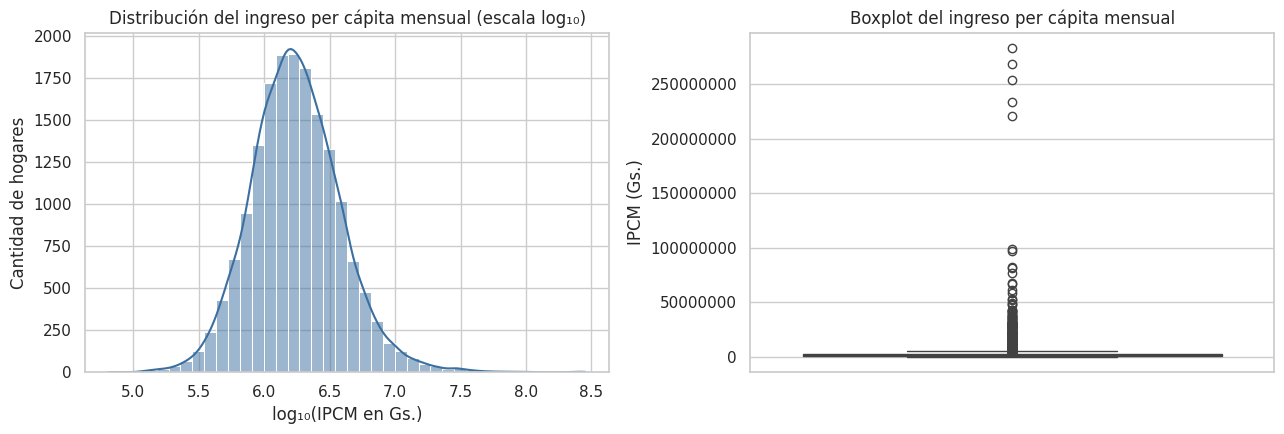

In [150]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(np.log10(df["IPCM"]), bins=40, kde=True, ax=axes[0], color="#3b6fa0")
axes[0].set_title("Distribución del ingreso per cápita mensual (escala log₁₀)")
axes[0].set_xlabel("log₁₀(IPCM en Gs.)")
axes[0].set_ylabel("Cantidad de hogares")

sns.boxplot(y=df["IPCM"], ax=axes[1], color="#3b6fa0")
axes[1].set_title("Boxplot del ingreso per cápita mensual")
axes[1].set_ylabel("IPCM (Gs.)")
axes[1].ticklabel_format(style="plain", axis="y")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/fig1_distribucion_ipcm.png", bbox_inches="tight")
plt.show()

*Interpretación:* en escala logarítmica, la distribución del ingreso per cápita se aproxima a una forma más simétrica (log-normal), lo que confirma que la asimetría observada en 4.1 es multiplicativa y no producto de un error de datos. El boxplot muestra visualmente la cola larga de valores altos identificada como "outliers" legítimos en la Etapa 3.

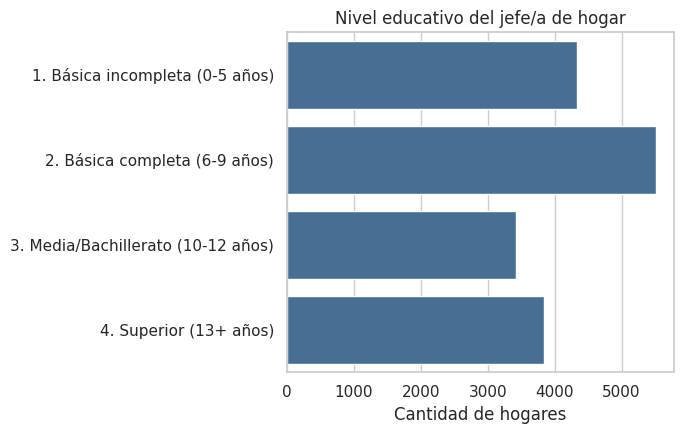

In [151]:
fig, ax = plt.subplots(figsize=(7, 4.5))
orden_educ = sorted(df["NIVEL_EDUC_JEFE"].dropna().unique())
sns.countplot(data=df, y="NIVEL_EDUC_JEFE", order=orden_educ, ax=ax, color="#3b6fa0")
ax.set_title("Nivel educativo del jefe/a de hogar")
ax.set_xlabel("Cantidad de hogares")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/fig2_nivel_educ_jefe.png", bbox_inches="tight")
plt.show()

*Interpretación:* la categoría más frecuente es "Básica completa (6-9 años)", seguida de cerca por "Superior (13+ años)". Hay una proporción relativamente baja de jefes/as con nivel "Media/Bachillerato" completo, lo que sugiere una distribución bimodal en la educación de los jefes de hogar paraguayos: muchos con educación básica solamente, y un grupo importante con estudios superiores.

### 4.4 Bivariado — Numérica vs. Numérica

Correlación de Pearson  (años de estudio vs. IPCM): r = 0.171  (p = 7.01e-113)
Correlación de Spearman (años de estudio vs. IPCM): rho = 0.451  (p = 0.00e+00)


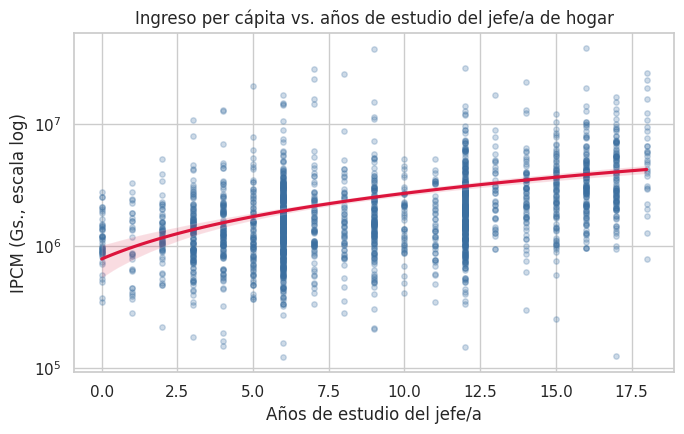

In [152]:
pearson_r, pearson_p = stats.pearsonr(df["ANIOS_ESTUDIO_JEFE"].dropna(),
                                        df.loc[df["ANIOS_ESTUDIO_JEFE"].notna(), "IPCM"])
spearman_r, spearman_p = stats.spearmanr(df["ANIOS_ESTUDIO_JEFE"], df["IPCM"], nan_policy="omit")

print(f"Correlación de Pearson  (años de estudio vs. IPCM): r = {pearson_r:.3f}  (p = {pearson_p:.2e})")
print(f"Correlación de Spearman (años de estudio vs. IPCM): rho = {spearman_r:.3f}  (p = {spearman_p:.2e})")

fig, ax = plt.subplots(figsize=(7, 4.5))
muestra = df.sample(2000, random_state=42)  # muestreamos para que el scatter sea legible
sns.regplot(data=muestra, x="ANIOS_ESTUDIO_JEFE", y="IPCM", ax=ax,
            scatter_kws={"alpha": 0.25, "s": 15, "color": "#3b6fa0"},
            line_kws={"color": "crimson"})
ax.set_yscale("log")
ax.set_title("Ingreso per cápita vs. años de estudio del jefe/a de hogar")
ax.set_xlabel("Años de estudio del jefe/a")
ax.set_ylabel("IPCM (Gs., escala log)")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/fig3_scatter_educacion_ingreso.png", bbox_inches="tight")
plt.show()

*Interpretación:* existe una correlación positiva, moderada y altamente significativa entre los años de estudio del jefe/a de hogar y el ingreso per cápita del hogar (Spearman más apropiado aquí por la asimetría de `IPCM`). Esto es consistente con la literatura sobre retornos a la educación, y sugiere que la educación podría actuar como variable de confusión en la relación entre internet e ingreso, algo a discutir en la Fase 2.

### 4.5 Bivariado — Numérica vs. Categórica

                   median       mean        std  count
TIENE_INTERNET                                        
0               1100000.0  1474903.0  3354115.0   6474
1               2207393.0  3228058.0  6333195.0  10618


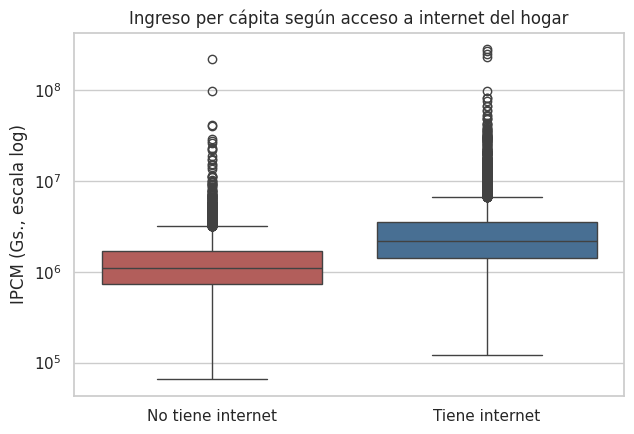

In [153]:
print(df.groupby("TIENE_INTERNET")["IPCM"].agg(["median", "mean", "std", "count"]).round(0))

fig, ax = plt.subplots(figsize=(6.5, 4.5))
sns.boxplot(data=df, x="TIENE_INTERNET", y="IPCM", hue="TIENE_INTERNET", ax=ax,
            palette=["#c0504d", "#3b6fa0"], legend=False)
ax.set_yscale("log")
ax.set_xticks([0, 1])
ax.set_xticklabels(["No tiene internet", "Tiene internet"])
ax.set_title("Ingreso per cápita según acceso a internet del hogar")
ax.set_xlabel("")
ax.set_ylabel("IPCM (Gs., escala log)")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/fig4_boxplot_internet_ipcm.png", bbox_inches="tight")
plt.show()

*Interpretación:* la mediana de ingreso per cápita de los hogares con internet es considerablemente más alta que la de los hogares sin internet. La diferencia visual es marcada; en la Fase 2 se contrastará formalmente si es estadísticamente significativa (Mann-Whitney U, dado el fuerte sesgo de `IPCM`).

### 4.6 Bivariado — Categórica vs. Categórica

In [154]:
tabla_area = pd.crosstab(df["AREA_DESC"], df["TIENE_INTERNET"], normalize="index").mul(100).round(1)
tabla_area.columns = ["% Sin internet", "% Con internet"]
print("Tenencia de internet según área de residencia:")
print(tabla_area)

tabla_educ = pd.crosstab(df["NIVEL_EDUC_JEFE"], df["TIENE_INTERNET"], normalize="index").mul(100).round(1)
tabla_educ.columns = ["% Sin internet", "% Con internet"]
print("\nTenencia de internet según nivel educativo del jefe/a:")
print(tabla_educ)

Tenencia de internet según área de residencia:
           % Sin internet  % Con internet
AREA_DESC                                
Rural                61.2            38.8
Urbana               20.4            79.6

Tenencia de internet según nivel educativo del jefe/a:
                                    % Sin internet  % Con internet
NIVEL_EDUC_JEFE                                                   
1. Básica incompleta (0-5 años)               63.7            36.3
2. Básica completa (6-9 años)                 44.4            55.6
3. Media/Bachillerato (10-12 años)            25.0            75.0
4. Superior (13+ años)                        10.8            89.2


*Interpretación:* se observa un patrón claramente monótono: a mayor nivel educativo del jefe/a de hogar, mayor proporción de hogares con internet (de ~36% en el nivel más bajo a ~89% en el nivel superior). La brecha urbano-rural también es muy marcada. Ambos patrones se formalizarán como hipótesis a contrastar en la Fase 2 (sección 5.4 de este notebook).

## Etapa 5 — Análisis descriptivo y exploratorio integrado

En esta etapa integramos los hallazgos anteriores en una caracterización conjunta del fenómeno, completando el mínimo de 8 visualizaciones distintas que exige la consigna.

> **Nota metodológica sobre la serie temporal:** la guía de la Fase 1 pide incluir al menos una visualización de serie temporal. La EPHC 2025 es un **corte transversal de un único año** (no un panel ni una serie de relevamientos repetidos a los mismos hogares), por lo que no existe una variable de tiempo que permita construir una serie temporal en sentido estricto. Documentamos esta limitación explícitamente y la sustituimos por una visualización de **tendencia sobre una variable ordinal** (deciles de ingreso), que cumple una función analítica similar: mostrar cómo evoluciona la proporción de hogares con internet a medida que aumenta, de forma ordenada, el ingreso del hogar.

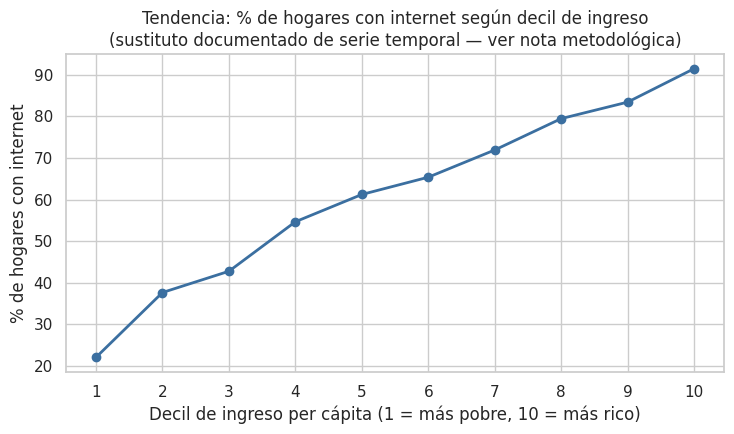

In [155]:
# Visualización 5 (sustituto documentado de serie temporal): tendencia por decil de ingreso
tendencia_decil = df.groupby("DECIL_ING")["TIENE_INTERNET"].mean().mul(100)

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(tendencia_decil.index, tendencia_decil.values, marker="o", color="#3b6fa0", linewidth=2)
ax.set_title("Tendencia: % de hogares con internet según decil de ingreso\n(sustituto documentado de serie temporal — ver nota metodológica)")
ax.set_xlabel("Decil de ingreso per cápita (1 = más pobre, 10 = más rico)")
ax.set_ylabel("% de hogares con internet")
ax.set_xticks(range(1, 11))
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/fig5_tendencia_decil_ingreso.png", bbox_inches="tight")
plt.show()

*Interpretación:* la relación es fuertemente creciente y casi monótona: pasar del decil 1 al decil 10 de ingreso implica pasar de aproximadamente 25-30% a más de 90% de hogares con acceso a internet.

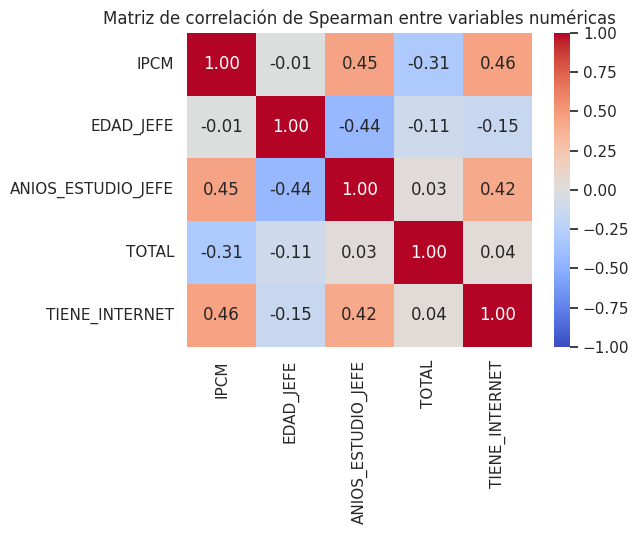

In [156]:
# Visualización 6: mapa de calor de correlaciones
vars_numericas = df[["IPCM", "EDAD_JEFE", "ANIOS_ESTUDIO_JEFE", "TOTAL", "TIENE_INTERNET"]]
corr = vars_numericas.corr(method="spearman")

fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Matriz de correlación de Spearman entre variables numéricas")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/fig6_heatmap_correlaciones.png", bbox_inches="tight")
plt.show()

*Interpretación:* `TIENE_INTERNET` correlaciona positivamente con `IPCM` y con `ANIOS_ESTUDIO_JEFE`, y negativamente con `EDAD_JEFE` (hogares con jefes/as más jóvenes tienden algo más a tener internet). El tamaño del hogar (`TOTAL`) tiene una correlación débil con todas las demás variables.

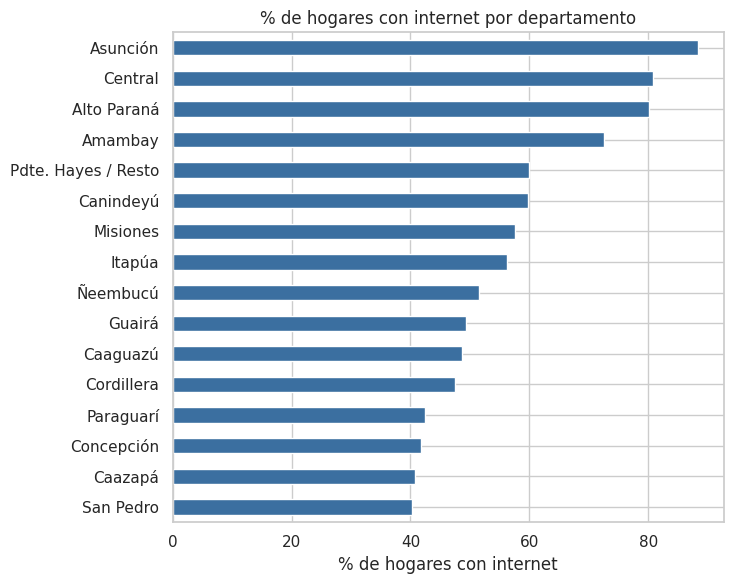

In [157]:
# Visualización 7: barras horizontales por departamento (ordenado) - sustituto de vista geográfica
tasa_dpto = df.groupby("DPTO_NOMBRE")["TIENE_INTERNET"].mean().mul(100).sort_values()

fig, ax = plt.subplots(figsize=(7.5, 6))
tasa_dpto.plot(kind="barh", ax=ax, color="#3b6fa0")
ax.set_title("% de hogares con internet por departamento")
ax.set_xlabel("% de hogares con internet")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/fig7_barras_departamento.png", bbox_inches="tight")
plt.show()

*Interpretación:* Asunción y Central (los departamentos más urbanizados, donde se concentra el Área Metropolitana) muestran las tasas más altas de acceso a internet, mientras que los departamentos con mayor proporción de población rural muestran las tasas más bajas — consistente con la brecha urbano-rural observada en 4.6.

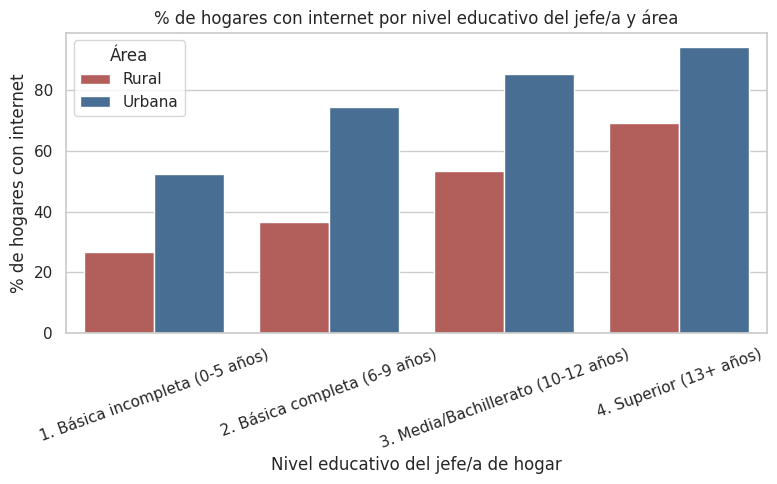

In [158]:
# Visualización 8: barras agrupadas - % internet por nivel educativo y área
fig, ax = plt.subplots(figsize=(8, 5))
resumen_grupo = df.groupby(["NIVEL_EDUC_JEFE", "AREA_DESC"])["TIENE_INTERNET"].mean().mul(100).reset_index()
sns.barplot(data=resumen_grupo, x="NIVEL_EDUC_JEFE", y="TIENE_INTERNET", hue="AREA_DESC",
            ax=ax, palette=["#c0504d", "#3b6fa0"])
ax.set_title("% de hogares con internet por nivel educativo del jefe/a y área")
ax.set_xlabel("Nivel educativo del jefe/a de hogar")
ax.set_ylabel("% de hogares con internet")
ax.tick_params(axis="x", rotation=20)
ax.legend(title="Área")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/fig8_barras_agrupadas_educ_area.png", bbox_inches="tight")
plt.show()

*Interpretación:* el efecto de la educación del jefe/a sobre el acceso a internet se mantiene **dentro** de cada área (urbana y rural), aunque el nivel base es sistemáticamente más bajo en el área rural en cada categoría educativa. Esto sugiere que educación y área tienen efectos independientes (no uno explica completamente al otro), algo que se puede formalizar en la Fase 3 con un modelo multivariado.

### 5.3 Patrones y anomalías identificados

1. **Brecha urbano-rural marcada:** 79,6% de los hogares urbanos tienen internet frente a 38,8% de los rurales (Etapa 4.6) — la brecha más grande detectada en todo el análisis.
2. **Gradiente educativo monótono:** la proporción de hogares con internet crece de forma escalonada y consistente con cada nivel educativo adicional del jefe/a de hogar (36% → 56% → 75% → 89%), sin ninguna inversión de tendencia.
3. **Asimetría extrema del ingreso:** el ingreso per cápita mensual tiene una cola derecha muy larga (asimetría alta, ver 4.1); usar la media sin corregir esta asimetría llevaría a conclusiones distorsionadas, por lo que se prioriza la mediana y pruebas no paramétricas para la Fase 2.
4. **Concentración geográfica:** los tres departamentos más poblados concentran una proporción importante de los hogares de la muestra, lo que amerita tenerlo en cuenta al generalizar resultados por departamento (algunos departamentos tienen pocas observaciones).

### 5.4 Hipótesis preliminares para la Fase 2

A partir de los patrones anteriores, se formulan las siguientes hipótesis a contrastar formalmente en la Fase 2:

**H1 — Área de residencia**
- H₀: La proporción de hogares con acceso a internet es igual entre el área urbana y el área rural.
- H₁: La proporción es distinta entre áreas.
- *Prueba sugerida:* chi-cuadrado de independencia / prueba z para dos proporciones.

**H2 — Nivel educativo del jefe/a de hogar**
- H₀: La proporción de hogares con internet no varía según el nivel educativo del jefe/a.
- H₁: La proporción sí varía según el nivel educativo.
- *Prueba sugerida:* chi-cuadrado de independencia (variable con 4 categorías).

**H3 — Ingreso**
- H₀: El ingreso per cápita mensual promedio no difiere entre hogares con y sin internet.
- H₁: Difiere.
- *Prueba sugerida:* U de Mann-Whitney (por la fuerte asimetría de `IPCM` detectada en 4.1).

**H4 — Educación e ingreso (correlación)**
- H₀: No existe correlación entre los años de estudio del jefe/a y el ingreso per cápita del hogar.
- H₁: Existe correlación.
- *Prueba sugerida:* prueba de significancia sobre el coeficiente de Spearman (ya estimado en 4.4; falta la prueba formal de significancia con intervalo de confianza).

**H5 — Tamaño del hogar**
- H₀: El tamaño del hogar (`TOTAL`) no difiere entre hogares con y sin internet.
- H₁: Difiere.
- *Prueba sugerida:* Mann-Whitney U o ANOVA/Kruskal-Wallis si se cruza además con área.

## Conclusión de la Fase 1

**Principales resultados:** el análisis exploratorio de los 17.092 hogares de la EPHC 2025 muestra que el acceso a internet en Paraguay está fuertemente asociado al área de residencia, al nivel educativo del jefe/a de hogar y al nivel de ingreso. La brecha urbano-rural (79,6% vs. 38,8%) es el patrón más marcado, seguida de un gradiente educativo consistente y una relación creciente con el ingreso (25-30% en el decil más pobre a más de 90% en el decil más rico).

**Respuesta parcial a la pregunta de investigación:** con base en el análisis descriptivo, sí se observa una variación clara y sistemática del acceso a internet según área, ingreso y educación del jefe/a de hogar. Queda pendiente para la Fase 2 confirmar si estas diferencias son estadísticamente significativas (más allá del azar muestral) y para la Fase 3 evaluar qué tan bien puede predecirse el acceso a internet de un hogar a partir de estas variables combinadas.

**Limitaciones detectadas:**
- Es un corte transversal: no permite establecer causalidad ni observar evolución temporal (ver nota metodológica de la Etapa 5).
- El ingreso (`IPCM`) es una variable derivada calculada por el INE, no observada directamente; hereda los supuestos metodológicos de ese cálculo.
- Algunos departamentos tienen pocas observaciones en la muestra, lo que puede afectar la precisión de las estimaciones a ese nivel de desagregación.

**Decisiones que condicionan las fases siguientes:**
- Se prioriza la mediana y las pruebas no paramétricas (Mann-Whitney, Kruskal-Wallis, chi-cuadrado) para la Fase 2, dado el fuerte sesgo de `IPCM` y el carácter categórico de la variable objetivo.
- La variable objetivo para la Fase 3 (modelado predictivo) será `TIENE_INTERNET` (clasificación binaria), con `AREA`, `IPCM`, `ANIOS_ESTUDIO_JEFE`, `EDAD_JEFE` y `TOTAL` como variables explicativas candidatas.

**Hipótesis que se llevan a la Fase 2:** las cinco hipótesis formuladas en la sección 5.4 (área, educación, ingreso, correlación educación-ingreso, y tamaño del hogar).

## Exportación del dataset limpio

Guardamos el dataset final (17.092 hogares, variables seleccionadas y transformadas) para su uso en la Fase 2.

In [159]:
columnas_finales = [
    "UPM", "NVIVI", "NHOGA", "DPTO", "DPTO_NOMBRE", "AREA", "AREA_DESC", "TOTAL",
    "V23A1", "TIENE_INTERNET", "V23C1", "V23C2",
    "EDAD_JEFE", "SEXO_JEFE_DESC", "ANIOS_ESTUDIO_JEFE", "NIVEL_EDUC_JEFE",
    "CAT_OCUP_JEFE_DESC", "IPCM", "QUINTIL_ING", "DECIL_ING", "FACTOR",
]
dataset_final = df[columnas_finales].copy()
dataset_final.to_csv(f"{OUTPUT_DIR}/dataset_limpio_internet_hogares.csv", index=False)

print(f"Dataset final exportado: {dataset_final.shape[0]:,} filas x {dataset_final.shape[1]} columnas")
dataset_final.head()

Dataset final exportado: 17,092 filas x 21 columnas


,UPM,NVIVI,NHOGA,DPTO,DPTO_NOMBRE,AREA,AREA_DESC,TOTAL,V23A1,TIENE_INTERNET,V23C1,V23C2,EDAD_JEFE,SEXO_JEFE_DESC,ANIOS_ESTUDIO_JEFE,NIVEL_EDUC_JEFE,CAT_OCUP_JEFE_DESC,IPCM,QUINTIL_ING,DECIL_ING,FACTOR
0,14,13,1,0,Asunción,1,Urbana,2,1,1,1.0,6.0,65,Hombre,15.0,4. Superior (13+ años),Inactivo/No aplica,9.470323e+06,5,10,100
1,14,15,1,0,Asunción,1,Urbana,2,6,0,NaN,NaN,78,Hombre,6.0,2. Básica completa (6-9 años),Inactivo/No aplica,2.080500e+06,4,7,124
2,14,16,1,0,Asunción,1,Urbana,3,1,1,1.0,6.0,40,Hombre,17.0,4. Superior (13+ años),Empleado/a privado/a,3.535490e+06,5,9,138
3,14,26,1,0,Asunción,1,Urbana,2,6,1,1.0,6.0,32,Hombre,12.0,3. Media/Bachillerato (10-12 años),Empleado/a privado/a,3.671471e+06,5,9,183
4,14,35,1,0,Asunción,1,Urbana,2,6,1,1.0,6.0,24,Hombre,12.0,3. Media/Bachillerato (10-12 años),Empleado/a privado/a,3.457301e+06,5,9,120


## Referencias

- Instituto Nacional de Estadística (INE), Paraguay — Encuesta Permanente de Hogares Continua (EPHC) 2025. Microdatos y diccionario de variables provistos por la cátedra.
- McKinney, W. — *Python for Data Analysis*, 3ª edición, O'Reilly.
- Tukey, J. W. — *Exploratory Data Analysis*, Addison-Wesley.

In [160]:
import os
# Cambia esta ruta a donde tengas guardado tu notebook en Google Drive
os.chdir('/content/drive/MyDrive/TP_Data_Science/notebooks')
print(os.listdir('.'))
!jupyter nbconvert --to html Fase1_AccesoInternet.ipynb

['Fase1_AccesoInternet.ipynb', 'Fase1_AccesoInternet.html']
[NbConvertApp] Converting notebook Fase1_AccesoInternet.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 8 image(s).
[NbConvertApp] Writing 1029629 bytes to Fase1_AccesoInternet.html


In [161]:
import pandas as pd

# Creamos la estructura de la bitácora exigida por la Etapa 3
bitacora_data = [
    {
        "Etapa / Variable": "Años de estudio (jefes)",
        "Decisión tomada": "Reemplazo de códigos '99' (No responde) por valores nulos (np.nan)",
        "Registros afectados": nr_anios_estudio,
        "Fundamentación metodológica": "Evitar sesgos matemáticos en promedios y modelos predictivos."
    },
    {
        "Etapa / Variable": "Ingresos (IPCM)",
        "Decisión tomada": "Conversión tipográfica robusta y manejo de comas decimales",
        "Registros afectados": len(ing_sel),
        "Fundamentación metodológica": "Asegurar formato numérico continuo estándar para análisis bivariado."
    },
    {
        "Etapa / Variable": "Estructura de Hogares",
        "Decisión tomada": "Filtro estricto de jefatura (P03 == 1) y merge por UPM/NVIVI/NHOGA",
        "Registros afectados": len(df),
        "Fundamentación metodológica": "Evitar duplicación artificial de filas al unificar fuentes a nivel de hogar."
    }
]

df_bitacora = pd.DataFrame(bitacora_data)

# Mostramos la tabla formateada en el notebook
display(df_bitacora)

# Exportamos la bitácora a CSV dentro de la carpeta output para el repositorio
df_bitacora.to_csv(f"{OUTPUT_DIR}/bitacora_limpieza.csv", index=False, encoding="utf-8")

,Etapa / Variable,Decisión tomada,Registros afectados,Fundamentación metodológica
0,Años de estudio (jefes),Reemplazo de códigos '99' (No responde) por va...,2,Evitar sesgos matemáticos en promedios y model...
1,Ingresos (IPCM),Conversión tipográfica robusta y manejo de com...,17092,Asegurar formato numérico continuo estándar pa...
2,Estructura de Hogares,Filtro estricto de jefatura (P03 == 1) y merge...,17092,Evitar duplicación artificial de filas al unif...


In [162]:
# Generador automatizado del Diccionario de Datos del Dataset Final
diccionario_final = pd.DataFrame({
    "Variable": df.columns,
    "Tipo de Dato": [str(df[col].dtype) for col in df.columns],
    "Valores No Nulos": [df[col].notna().sum() for col in df.columns],
    "% Faltantes": [round(df[col].isna().mean() * 100, 2) for col in df.columns],
    "Valores Únicos": [df[col].nunique() for col in df.columns]
})

display(diccionario_final)

# Exportar a CSV para adjuntar al repositorio
diccionario_final.to_csv(f"{OUTPUT_DIR}/diccionario_datos_final.csv", index=False, encoding="utf-8")

,Variable,Tipo de Dato,Valores No Nulos,% Faltantes,Valores Únicos
0,UPM,int64,17092,0.00,1750
1,NVIVI,int64,17092,0.00,160
2,NHOGA,int64,17092,0.00,2
3,DPTO,int64,17092,0.00,16
4,AREA,int64,17092,0.00,2
5,TOTAL,int64,17092,0.00,17
6,V23A1,int64,17092,0.00,2
7,V23B,int64,17092,0.00,2
8,V23C1,float64,10618,37.88,2
9,V23C2,float64,10618,37.88,2
